In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import optuna

RANDOM_STATE = 42
ORIGINAL_CLASS_NAMES = {0: "Home win", 1: "Draw", 2: "Away win"}


In [2]:
def validate_original_labels(y, split_name):
    values = set(pd.Series(y).dropna().astype(int).unique())
    expected = {0, 1, 2}
    unexpected = values - expected
    if unexpected:
        raise ValueError(
            f"{split_name} contains unexpected winner_code values: {sorted(unexpected)}"
        )


def positive_class_probability(model, X):
    """Return P(target=1), regardless of the internal class-column order."""
    classes = np.asarray(model.classes_, dtype=int)
    positive_columns = np.flatnonzero(classes == 1)
    if len(positive_columns) != 1:
        raise ValueError(f"Expected binary classes including 1, found {classes.tolist()}")
    return model.predict_proba(X)[:, positive_columns[0]]


def binary_metrics(y_true, positive_probs, threshold=0.5):
    y_true = np.asarray(y_true, dtype=int)
    positive_probs = np.asarray(positive_probs, dtype=float)
    predicted = (positive_probs >= threshold).astype(int)

    return {
        "log_loss": log_loss(y_true, positive_probs, labels=[0, 1]),
        "brier_score": brier_score_loss(y_true, positive_probs),
        "roc_auc": roc_auc_score(y_true, positive_probs),
        "average_precision": average_precision_score(y_true, positive_probs),
        "accuracy_at_0.5": accuracy_score(y_true, predicted),
        "precision_at_0.5": precision_score(y_true, predicted, zero_division=0),
        "recall_at_0.5": recall_score(y_true, predicted, zero_division=0),
        "f1_at_0.5": f1_score(y_true, predicted, zero_division=0),
    }


def plot_binary_calibration(y_true, positive_probs, title, n_bins=10):
    prob_true, prob_pred = calibration_curve(
        y_true, positive_probs, n_bins=n_bins, strategy="quantile"
    )
    plt.figure(figsize=(7, 6))
    plt.plot(prob_pred, prob_true, marker="o", label=title)
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed frequency")
    plt.title(f"Calibration: {title}")
    plt.grid(True)
    plt.legend()
    plt.show()


def calibration_table(y_true, positive_probs, n_bins=10):
    frame = pd.DataFrame({"actual": np.asarray(y_true), "probability": positive_probs})
    frame["bin"] = pd.qcut(
        frame["probability"], q=n_bins, duplicates="drop"
    )
    return (
        frame.groupby("bin", observed=True)
        .agg(
            count=("actual", "size"),
            mean_probability=("probability", "mean"),
            observed_rate=("actual", "mean"),
        )
        .reset_index()
    )


In [3]:
features = pd.read_csv("stored_features/match_features_c_25_mu1_0.20_mu2_0.10.csv")

features["date"] = pd.to_datetime(features["date"], errors="raise")
features = (
    features.loc[
        (features["date"] < pd.Timestamp("2026-06-01"))
        & (features["date"] > pd.Timestamp("1920-01-01"))
    ]
    .sort_values(by="date", ascending=True, kind="stable")
    .reset_index(drop=True)
)

assert features["date"].is_monotonic_increasing
validate_original_labels(features["winner_code"], "Full dataset")
print(features["winner_code"].value_counts(dropna=False).sort_index())


winner_code
0    16816
1    10389
2    17556
Name: count, dtype: int64


In [4]:
# Preserve the original notebook's selected feature columns.
features = features.drop(
    columns=[
        "match_id",
        "date",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "winner",
        #"home_avg_goal_difference_last_10",
        #"away_avg_goal_difference_last_10",
        "home_failed_score_rate_last_5",
        "away_failed_score_rate_last_5",
        #"home_days_since_last_game",
        #"away_days_since_last_game",
        "diff_under_1_5_rate",
        "home_over_2_5_rate_last_5",
        "away_over_2_5_rate_last_5",
        "home_over_3_5_rate_last_5",
        "away_over_3_5_rate_last_5",
        "diff_over_2_5_rate",
        "home_under_1_5_rate_last_5",
        "away_under_1_5_rate_last_5",
        #"home_pi_expected_gd",
        #"away_pi_expected_gd",
    ]
)


In [5]:
# Build two independent binary targets from the agreed original coding.
original_y = features["winner_code"].astype(int)
X = features.drop(columns=["winner_code"])

y_home_win = (original_y == 0).astype(int)  # 1 = home win; 0 = draw or away win
y_away_win = (original_y == 2).astype(int)  # 1 = away win; 0 = draw or home win

if len(features) < 20:
    raise ValueError("The dataset is too small for a chronological train/test split.")

test_start = int(len(features) * 0.80)

X_train_val_raw = X.iloc[:test_start].copy()
X_test_raw = X.iloc[test_start:].copy()

y_home_train_val = y_home_win.iloc[:test_start].copy()
y_home_test = y_home_win.iloc[test_start:].copy()

y_away_train_val = y_away_win.iloc[:test_start].copy()
y_away_test = y_away_win.iloc[test_start:].copy()

original_y_test = original_y.iloc[test_start:].copy()

print("Train/validation rows:", len(X_train_val_raw))
print("Untouched test rows:", len(X_test_raw))
print("Home-win train prevalence:", y_home_train_val.mean())
print("Away-win train prevalence:", y_away_train_val.mean())


Train/validation rows: 35808
Untouched test rows: 8953
Home-win train prevalence: 0.3762008489722967
Away-win train prevalence: 0.3928172475424486


In [6]:
tscv = TimeSeriesSplit(n_splits=5)


def make_objective(X_raw, y, model_name):
    def objective(trial):
        params = {
            "objective": "binary:logistic",
            "eval_metric": "logloss",
            "random_state": RANDOM_STATE,
            "n_estimators": trial.suggest_int("n_estimators", 200, 1000, step=20),
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
            "max_depth": trial.suggest_int("max_depth", 2, 6),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0, step=0.1),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0, step=0.05),
            "colsample_bytree": trial.suggest_float(
                "colsample_bytree", 0.6, 1.0, step=0.05
            ),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 50.0, log=True),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 10.0, log=True),
            "tree_method": "hist",
            "n_jobs": -1,
        }

        fold_brier = []
        fold_logloss = []
        fold_auc = []

        for fold_number, (train_idx, val_idx) in enumerate(tscv.split(X_raw), start=1):
            fold_X_train_raw = X_raw.iloc[train_idx]
            fold_X_val_raw = X_raw.iloc[val_idx]
            fold_y_train = y.iloc[train_idx]
            fold_y_val = y.iloc[val_idx]

            if fold_y_train.nunique() < 2 or fold_y_val.nunique() < 2:
                raise optuna.TrialPruned(
                    f"{model_name}, fold {fold_number}: only one target class present."
                )

            imputer = SimpleImputer(strategy="median")
            fold_X_train = imputer.fit_transform(fold_X_train_raw)
            fold_X_val = imputer.transform(fold_X_val_raw)

            model = xgb.XGBClassifier(**params)
            model.fit(
                fold_X_train,
                fold_y_train,
                eval_set=[(fold_X_val, fold_y_val)],
                verbose=False,
            )

            probabilities = positive_class_probability(model, fold_X_val)
            fold_brier.append(brier_score_loss(fold_y_val, probabilities))
            fold_logloss.append(log_loss(fold_y_val, probabilities, labels=[0, 1]))
            fold_auc.append(roc_auc_score(fold_y_val, probabilities))

            running_score = float(np.mean(fold_brier))
            trial.report(running_score, step=fold_number)
            if trial.should_prune():
                raise optuna.TrialPruned()

        mean_brier = float(np.mean(fold_brier))
        trial.set_user_attr("mean_log_loss", float(np.mean(fold_logloss)))
        trial.set_user_attr("mean_roc_auc", float(np.mean(fold_auc)))
        trial.set_user_attr("brier_std", float(np.std(fold_brier)))
        return mean_brier

    return objective


In [7]:
home_study = optuna.create_study(
    study_name="home_win_vs_not_home_win",
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
)

home_study.optimize(
    make_objective(X_train_val_raw, y_home_train_val, "home-win model"),
    n_trials=50,
    show_progress_bar=True,
)

print("Best home-win parameters:", home_study.best_params)
print("Best home-win CV Brier score:", home_study.best_value)


[I 2026-07-14 01:13:44,911] A new study created in memory with name: home_win_vs_not_home_win


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-14 01:13:54,349] Trial 0 finished with value: 0.1930118680000305 and parameters: {'n_estimators': 500, 'learning_rate': 0.1358198535217987, 'max_depth': 5, 'min_child_weight': 12, 'gamma': 0.7000000000000001, 'subsample': 0.65, 'colsample_bytree': 0.6, 'reg_lambda': 21.76624112345367, 'reg_alpha': 0.040428727350273294}. Best is trial 0 with value: 0.1930118680000305.
[I 2026-07-14 01:14:06,565] Trial 1 finished with value: 0.1849791079759598 and parameters: {'n_estimators': 780, 'learning_rate': 0.020846957895078073, 'max_depth': 6, 'min_child_weight': 17, 'gamma': 1.0, 'subsample': 0.65, 'colsample_bytree': 0.65, 'reg_lambda': 0.6624310605949987, 'reg_alpha': 0.014077923139972392}. Best is trial 1 with value: 0.1849791079759598.
[I 2026-07-14 01:14:14,189] Trial 2 finished with value: 0.18471001982688903 and parameters: {'n_estimators': 540, 'learning_rate': 0.03596444270828742, 'max_depth': 5, 'min_child_weight': 3, 'gamma': 1.4000000000000001, 'subsample': 0.75, 'colsampl

In [8]:
away_study = optuna.create_study(
    study_name="away_win_vs_not_away_win",
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE + 1),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
)

away_study.optimize(
    make_objective(X_train_val_raw, y_away_train_val, "away-win model"),
    n_trials=50,
    show_progress_bar=True,
)

print("Best away-win parameters:", away_study.best_params)
print("Best away-win CV Brier score:", away_study.best_value)


[I 2026-07-14 01:17:28,340] A new study created in memory with name: away_win_vs_not_away_win


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-14 01:17:30,482] Trial 0 finished with value: 0.18715511858463288 and parameters: {'n_estimators': 280, 'learning_rate': 0.0682339528443407, 'max_depth': 2, 'min_child_weight': 5, 'gamma': 1.6, 'subsample': 0.95, 'colsample_bytree': 0.85, 'reg_lambda': 2.887889544752868, 'reg_alpha': 1.4930795478222954e-05}. Best is trial 0 with value: 0.18715511858463288.
[I 2026-07-14 01:17:40,473] Trial 1 finished with value: 0.19318823516368866 and parameters: {'n_estimators': 800, 'learning_rate': 0.04432364397243556, 'max_depth': 6, 'min_child_weight': 6, 'gamma': 0.2, 'subsample': 0.95, 'colsample_bytree': 0.65, 'reg_lambda': 1.2389516898154314, 'reg_alpha': 0.0007880954608106449}. Best is trial 0 with value: 0.18715511858463288.
[I 2026-07-14 01:17:42,357] Trial 2 finished with value: 0.18711356222629547 and parameters: {'n_estimators': 260, 'learning_rate': 0.10937127171867443, 'max_depth': 6, 'min_child_weight': 20, 'gamma': 1.9000000000000001, 'subsample': 1.0, 'colsample_bytree':

In [17]:
import numpy as np
import pandas as pd

from sklearn.base import clone
tscv = TimeSeriesSplit(n_splits=5)

oof_parts = []

va_home_model = xgb.XGBClassifier(objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        tree_method="hist",
        n_jobs=-1,
        **home_study.best_params,
    )
va_away_model = xgb.XGBClassifier(objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        tree_method="hist",
        n_jobs=-1,
        **away_study.best_params,
    )

for fold_number, (train_idx, val_idx) in enumerate(
    tscv.split(X_train_val_raw),
    start=1,
):
    fold_X_train_raw = X_train_val_raw.iloc[train_idx]
    fold_X_val_raw = X_train_val_raw.iloc[val_idx]

    fold_y_home_train = y_home_train_val.iloc[train_idx]
    fold_y_away_train = y_away_train_val.iloc[train_idx]

    fold_actual_result = y_home_train_val.iloc[val_idx]

    fold_home_model = clone(va_home_model)
    fold_away_model = clone(va_away_model)

    fold_home_model.fit(
        fold_X_train_raw,
        fold_y_home_train,
    )

    fold_away_model.fit(
        fold_X_train_raw,
        fold_y_away_train,
    )

    fold_prob_home = positive_class_probability(
        fold_home_model,
        fold_X_val_raw,
    )

    fold_prob_away = positive_class_probability(
        fold_away_model,
        fold_X_val_raw,
    )

    fold_output = pd.DataFrame(
        {
            "fold": fold_number,
            "actual_code": fold_actual_result.to_numpy(),
            "actual_result": [
                ORIGINAL_CLASS_NAMES[int(code)]
                for code in fold_actual_result
            ],
            "prob_home_win": fold_prob_home,
            "prob_away_win": fold_prob_away,
        },
        index=fold_X_val_raw.index,
    )

    oof_parts.append(fold_output)


oof_prediction_output = (
    pd.concat(oof_parts)
    .sort_index()
)

display(oof_prediction_output.head())
print("OOF validation rows:", len(oof_prediction_output))

,fold,actual_code,actual_result,prob_home_win,prob_away_win
5968,1,0,Home win,0.480995,0.222653
5969,1,0,Home win,0.225422,0.598964
5970,1,1,Draw,0.622833,0.154814
5971,1,0,Home win,0.284410,0.556003
5972,1,1,Draw,0.646116,0.148358


OOF validation rows: 29840


In [ ]:
gammas = np.arange(0.35, 0.65, 0.005)  # home threshold
betas = np.arange(0.35, 0.65, 0.005)   # away threshold

labels = ["Home win", "Draw", "Away win"]

actual = oof_prediction_output["actual_result"].to_numpy()
home_probs = oof_prediction_output["prob_home_win"].to_numpy()
away_probs = oof_prediction_output["prob_away_win"].to_numpy()

results = []

for gamma in gammas:
    for beta in betas:

        home_pass = home_probs >= gamma
        away_pass = away_probs >= beta

        pred = np.full(
            len(oof_prediction_output),
            "Draw",
            dtype=object,
        )

        # Exactly one classifier passes.
        pred[home_pass & ~away_pass] = "Home win"
        pred[away_pass & ~home_pass] = "Away win"

        # Both classifiers pass.
        both_pass = home_pass & away_pass

        # Compare how far each probability exceeds its threshold.
        home_relative_confidence = home_probs / gamma
        away_relative_confidence = away_probs / beta

        pred[
            both_pass
            & (home_relative_confidence >= away_relative_confidence)
        ] = "Home win"

        pred[
            both_pass
            & (away_relative_confidence > home_relative_confidence)
        ] = "Away win"

        class_precision = precision_score(
            actual,
            pred,
            labels=labels,
            average=None,
            zero_division=0,
        )

        class_recall = recall_score(
            actual,
            pred,
            labels=labels,
            average=None,
            zero_division=0,
        )

        results.append(
            {
                "gamma_home": gamma,
                "beta_away": beta,

                "macro_precision": precision_score(
                    actual,
                    pred,
                    labels=labels,
                    average="macro",
                    zero_division=0,
                ),

                "weighted_precision": precision_score(
                    actual,
                    pred,
                    labels=labels,
                    average="weighted",
                    zero_division=0,
                ),

                "accuracy": accuracy_score(actual, pred),

                "macro_recall": recall_score(
                    actual,
                    pred,
                    labels=labels,
                    average="macro",
                    zero_division=0,
                ),

                "macro_f1": f1_score(
                    actual,
                    pred,
                    labels=labels,
                    average="macro",
                    zero_division=0,
                ),

                "home_precision": class_precision[0],
                "draw_precision": class_precision[1],
                "away_precision": class_precision[2],

                "home_recall": class_recall[0],
                "draw_recall": class_recall[1],
                "away_recall": class_recall[2],

                "predicted_home_wins": int(
                    (pred == "Home win").sum()
                ),
                "predicted_draws": int(
                    (pred == "Draw").sum()
                ),
                "predicted_away_wins": int(
                    (pred == "Away win").sum()
                ),
            }
        )


threshold_results = pd.DataFrame(results)


     gamma_home  beta_away  macro_precision  weighted_precision  accuracy  \
0          0.45       0.35         0.261607            0.389491  0.181334   
1          0.45       0.36         0.259948            0.387814  0.186528   
2          0.45       0.37         0.258513            0.386309  0.191756   
3          0.45       0.38         0.256582            0.384282  0.196515   
4          0.45       0.39         0.254721            0.382274  0.202178   
..          ...        ...              ...                 ...       ...   
615        0.64       0.61         0.200699            0.283640  0.286126   
616        0.64       0.62         0.199698            0.282539  0.287399   
617        0.64       0.63         0.198801            0.281552  0.288673   
618        0.64       0.64         0.197774            0.280423  0.289712   
619        0.64       0.65         0.196847            0.279403  0.290985   

     macro_recall  macro_f1  home_precision  draw_precision  away_precision

In [21]:
display(threshold_results)

,gamma_home,beta_away,macro_precision,weighted_precision,accuracy,macro_recall,macro_f1,home_precision,draw_precision,away_precision,home_recall,draw_recall,away_recall,predicted_home_wins,predicted_draws,predicted_away_wins
0,0.45,0.35,0.261607,0.389491,0.181334,0.113910,0.156480,0.381460,0.403361,0.0,0.210128,0.131603,0.0,10410,3570,15860
1,0.45,0.36,0.259948,0.387814,0.186528,0.118401,0.161169,0.382015,0.397830,0.0,0.211081,0.144124,0.0,10442,3964,15434
2,0.45,0.37,0.258513,0.386309,0.191756,0.123038,0.165786,0.382291,0.393248,0.0,0.211557,0.157558,0.0,10458,4384,14998
3,0.45,0.38,0.256582,0.384282,0.196515,0.127197,0.169553,0.382656,0.387090,0.0,0.212245,0.169347,0.0,10482,4787,14571
4,0.45,0.39,0.254721,0.382274,0.202178,0.132282,0.173945,0.382804,0.381358,0.0,0.212509,0.184336,0.0,10491,5289,14060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
615,0.64,0.61,0.200699,0.283640,0.286126,0.248582,0.186548,0.235757,0.366339,0.0,0.047518,0.698227,0.0,3809,20855,5176
616,0.64,0.62,0.199698,0.282539,0.287399,0.249739,0.185954,0.235757,0.363335,0.0,0.047518,0.701700,0.0,3809,21132,4899
617,0.64,0.63,0.198801,0.281552,0.288673,0.250897,0.185440,0.235757,0.360645,0.0,0.047518,0.705173,0.0,3809,21395,4636
618,0.64,0.64,0.197774,0.280423,0.289712,0.251841,0.184751,0.235757,0.357565,0.0,0.047518,0.708006,0.0,3809,21666,4365


In [22]:
minimum_macro_recall = 0.25

eligible_results = threshold_results.loc[
    threshold_results["macro_recall"] >= minimum_macro_recall
].copy()

if eligible_results.empty:
    raise ValueError(
        "No threshold pair satisfies the minimum macro recall. "
        "Lower minimum_macro_recall."
    )

eligible_results = eligible_results.sort_values(
    by=[
        "macro_precision",
        "macro_f1",
        "accuracy",
    ],
    ascending=False,
).reset_index(drop=True)

display(eligible_results.head(20))

best_gamma = eligible_results.loc[0, "gamma_home"]
best_beta = eligible_results.loc[0, "beta_away"]

print(f"Best home threshold: {best_gamma:.2f}")
print(f"Best away threshold: {best_beta:.2f}")
print()
print(eligible_results.loc[0])

,gamma_home,beta_away,macro_precision,weighted_precision,accuracy,macro_recall,macro_f1,home_precision,draw_precision,away_precision,home_recall,draw_recall,away_recall,predicted_home_wins,predicted_draws,predicted_away_wins
0,0.63,0.65,0.198812,0.283824,0.289377,0.250434,0.184763,0.244229,0.352207,0.0,0.052069,0.699232,0.0,4029,21723,4088
1,0.64,0.63,0.198801,0.281552,0.288673,0.250897,0.185440,0.235757,0.360645,0.0,0.047518,0.705173,0.0,3809,21395,4636
2,0.64,0.64,0.197774,0.280423,0.289712,0.251841,0.184751,0.235757,0.357565,0.0,0.047518,0.708006,0.0,3809,21666,4365
3,0.64,0.65,0.196847,0.279403,0.290985,0.252999,0.184188,0.235757,0.354783,0.0,0.047518,0.711479,0.0,3809,21943,4088


Best home threshold: 0.63
Best away threshold: 0.65

gamma_home                 0.630000
beta_away                  0.650000
macro_precision            0.198812
weighted_precision         0.283824
accuracy                   0.289377
macro_recall               0.250434
macro_f1                   0.184763
home_precision             0.244229
draw_precision             0.352207
away_precision             0.000000
home_recall                0.052069
draw_recall                0.699232
away_recall                0.000000
predicted_home_wins     4029.000000
predicted_draws        21723.000000
predicted_away_wins     4088.000000
Name: 0, dtype: float64


In [23]:
def fit_final_binary_model(best_params, X_train_raw, y_train, X_test_raw):
    imputer = SimpleImputer(strategy="median")
    X_train = imputer.fit_transform(X_train_raw)
    X_test = imputer.transform(X_test_raw)

    model = xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        tree_method="hist",
        n_jobs=-1,
        **best_params,
    )
    model.fit(X_train, y_train, verbose=False)
    probabilities = positive_class_probability(model, X_test)
    return model, imputer, probabilities


home_model, home_imputer, prob_home_win = fit_final_binary_model(
    home_study.best_params, X_train_val_raw, y_home_train_val, X_test_raw
)

away_model, away_imputer, prob_away_win = fit_final_binary_model(
    away_study.best_params, X_train_val_raw, y_away_train_val, X_test_raw
)


In [24]:
home_results = binary_metrics(y_home_test, prob_home_win)
away_results = binary_metrics(y_away_test, prob_away_win)

results_table = pd.DataFrame(
    [home_results, away_results],
    index=["Home win vs not home win", "Away win vs not away win"],
)

display(results_table)


,log_loss,brier_score,roc_auc,average_precision,accuracy_at_0.5,precision_at_0.5,recall_at_0.5,f1_at_0.5
Home win vs not home win,0.523306,0.175951,0.793609,0.700657,0.727689,0.678614,0.515097,0.585656
Away win vs not away win,0.524817,0.175923,0.798594,0.726089,0.738300,0.697827,0.579656,0.633276


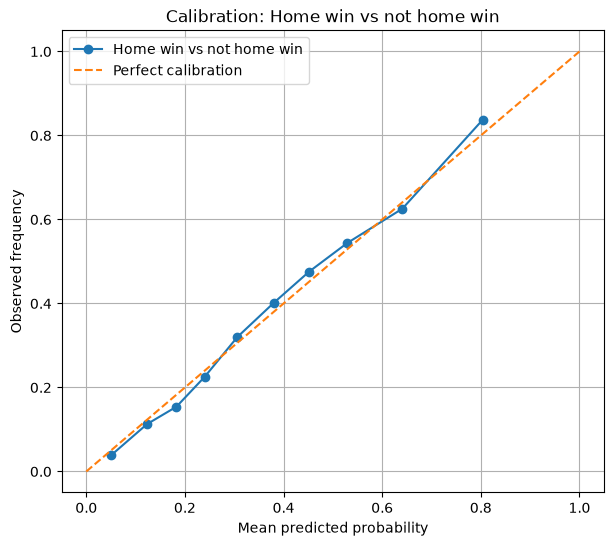

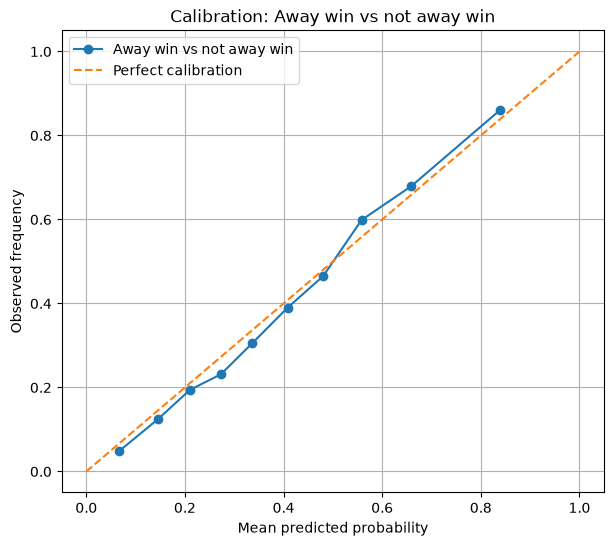

Home-win calibration table


,bin,count,mean_probability,observed_rate
0,"(0.014699999999999998, 0.0863]",896,0.050808,0.039062
1,"(0.0863, 0.155]",895,0.123214,0.112849
2,"(0.155, 0.21]",895,0.182778,0.154190
3,"(0.21, 0.272]",895,0.240255,0.225698
4,"(0.272, 0.343]",896,0.306471,0.320312
5,"(0.343, 0.417]",895,0.379758,0.401117
6,"(0.417, 0.487]",895,0.451984,0.475978
7,"(0.487, 0.577]",895,0.529350,0.544134
8,"(0.577, 0.703]",895,0.640898,0.625698
9,"(0.703, 0.962]",896,0.803507,0.837054


Away-win calibration table


,bin,count,mean_probability,observed_rate
0,"(0.0168, 0.114]",896,0.067290,0.049107
1,"(0.114, 0.178]",895,0.144754,0.124022
2,"(0.178, 0.241]",895,0.210342,0.194413
3,"(0.241, 0.304]",895,0.272762,0.231285
4,"(0.304, 0.371]",896,0.336922,0.305804
5,"(0.371, 0.442]",895,0.408118,0.389944
6,"(0.442, 0.519]",895,0.480029,0.464804
7,"(0.519, 0.602]",895,0.558363,0.598883
8,"(0.602, 0.733]",895,0.658968,0.679330
9,"(0.733, 0.969]",896,0.838965,0.860491


In [25]:
plot_binary_calibration(
    y_home_test, prob_home_win, "Home win vs not home win"
)
plot_binary_calibration(
    y_away_test, prob_away_win, "Away win vs not away win"
)

print("Home-win calibration table")
display(calibration_table(y_home_test, prob_home_win))

print("Away-win calibration table")
display(calibration_table(y_away_test, prob_away_win))


In [26]:
prediction_output = pd.DataFrame(
    {
        "actual_code": original_y_test.to_numpy(),
        "actual_result": [
            ORIGINAL_CLASS_NAMES[int(code)]
            for code in original_y_test
        ],
        "actual_home_win": y_home_test.to_numpy(),
        "actual_away_win": y_away_test.to_numpy(),
        "prob_home_win": prob_home_win,
        "prob_not_home_win": 1.0 - prob_home_win,
        "prob_away_win": prob_away_win,
        "prob_not_away_win": 1.0 - prob_away_win,
        "home_plus_away_probability": prob_home_win + prob_away_win,
        "residual_draw_diagnostic": (
            1.0 - prob_home_win - prob_away_win
        ),
    },
    index=X_test_raw.index,
)

In [27]:
# threshold_results = (
#     pd.DataFrame(results)
#     .sort_values(
#         [
#             "accuracy",
#             "macro_precision",
#             "macro_f1",
#         ],
#         ascending=False,
#     )
#     .reset_index(drop=True)
# )

# display(threshold_results.head(20))

# best_gamma = threshold_results.loc[0, "gamma_home"]
# best_beta = threshold_results.loc[0, "beta_away"]

# print(f"Best home threshold gamma: {best_gamma:.2f}")
# print(f"Best away threshold beta:  {best_beta:.2f}")
# print()
# print(threshold_results.loc[0])

In [28]:
gamma = best_gamma
beta = best_beta

home_pass = prediction_output["prob_home_win"] > gamma
away_pass = prediction_output["prob_away_win"] > beta

prediction_output["home_win_prediction"] = home_pass.astype(int)
prediction_output["away_win_prediction"] = away_pass.astype(int)

prediction_output["predicted_result"] = "Draw"

prediction_output.loc[
    home_pass & ~away_pass,
    "predicted_result",
] = "Home win"

prediction_output.loc[
    away_pass & ~home_pass,
    "predicted_result",
] = "Away win"

both_pass = home_pass & away_pass

home_relative_confidence = (
    prediction_output["prob_home_win"] / gamma
)

away_relative_confidence = (
    prediction_output["prob_away_win"] / beta
)

prediction_output.loc[
    both_pass
    & (home_relative_confidence >= away_relative_confidence),
    "predicted_result",
] = "Home win"

prediction_output.loc[
    both_pass
    & (away_relative_confidence > home_relative_confidence),
    "predicted_result",
] = "Away win"

display(prediction_output.head(20))

,actual_code,actual_result,actual_home_win,actual_away_win,prob_home_win,prob_not_home_win,prob_away_win,prob_not_away_win,home_plus_away_probability,residual_draw_diagnostic,home_win_prediction,away_win_prediction,predicted_result
35808,0,Home win,1,0,0.724400,0.275600,0.112599,0.887401,0.836999,0.163001,1,0,Home win
35809,0,Home win,1,0,0.649843,0.350157,0.136608,0.863392,0.786450,0.213550,1,0,Home win
35810,2,Away win,0,1,0.191849,0.808151,0.488248,0.511752,0.680097,0.319903,0,0,Draw
35811,0,Home win,1,0,0.365705,0.634295,0.297051,0.702949,0.662756,0.337244,0,0,Draw
35812,2,Away win,0,1,0.314662,0.685338,0.410427,0.589573,0.725089,0.274911,0,0,Draw
35813,0,Home win,1,0,0.072031,0.927969,0.744810,0.255190,0.816841,0.183159,0,1,Away win
35814,2,Away win,0,1,0.260225,0.739775,0.456497,0.543503,0.716722,0.283278,0,0,Draw
35815,2,Away win,0,1,0.575658,0.424342,0.191621,0.808379,0.767279,0.232721,0,0,Draw
35816,0,Home win,1,0,0.178091,0.821909,0.544879,0.455121,0.722970,0.277030,0,0,Draw
35817,1,Draw,0,0,0.493798,0.506202,0.225187,0.774813,0.718985,0.281014,0,0,Draw


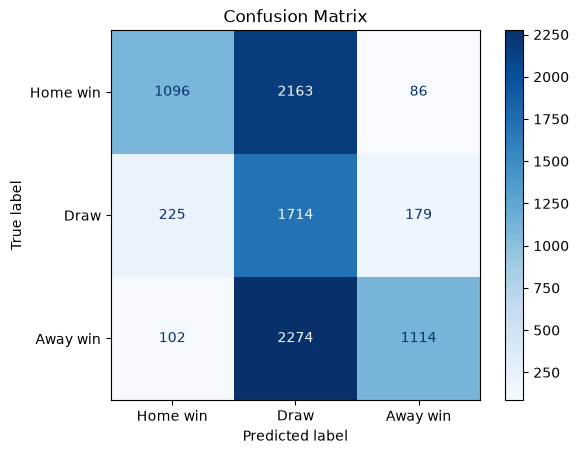


Home Win Metrics


,Home
Log Loss,0.523306
Brier Score,0.175951
ROC AUC,0.793609
Average Precision,0.700657
Accuracy,0.712275
Precision,0.770204
Recall,0.327653
F1,0.459732



Away Win Metrics


,Away
Log Loss,0.524817
Brier Score,0.175923
ROC AUC,0.798594
Average Precision,0.726089
Accuracy,0.705015
Precision,0.807832
Recall,0.319198
F1,0.457589


In [29]:

# ==========================================================
# Multi-class confusion matrix
# ==========================================================

labels = ["Home win", "Draw", "Away win"]

cm = confusion_matrix(
    prediction_output["actual_result"],
    prediction_output["predicted_result"],
    labels=labels,
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels,
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


# ==========================================================
# Home-win metrics
# ==========================================================

home_metrics = {
    "Log Loss": log_loss(
        prediction_output["actual_home_win"],
        prediction_output["prob_home_win"],
    ),
    "Brier Score": brier_score_loss(
        prediction_output["actual_home_win"],
        prediction_output["prob_home_win"],
    ),
    "ROC AUC": roc_auc_score(
        prediction_output["actual_home_win"],
        prediction_output["prob_home_win"],
    ),
    "Average Precision": average_precision_score(
        prediction_output["actual_home_win"],
        prediction_output["prob_home_win"],
    ),
    "Accuracy": accuracy_score(
        prediction_output["actual_home_win"],
        prediction_output["home_win_prediction"],
    ),
    "Precision": precision_score(
        prediction_output["actual_home_win"],
        prediction_output["home_win_prediction"],
        zero_division=0,
    ),
    "Recall": recall_score(
        prediction_output["actual_home_win"],
        prediction_output["home_win_prediction"],
        zero_division=0,
    ),
    "F1": f1_score(
        prediction_output["actual_home_win"],
        prediction_output["home_win_prediction"],
        zero_division=0,
    ),
}

# ==========================================================
# Away-win metrics
# ==========================================================

away_metrics = {
    "Log Loss": log_loss(
        prediction_output["actual_away_win"],
        prediction_output["prob_away_win"],
    ),
    "Brier Score": brier_score_loss(
        prediction_output["actual_away_win"],
        prediction_output["prob_away_win"],
    ),
    "ROC AUC": roc_auc_score(
        prediction_output["actual_away_win"],
        prediction_output["prob_away_win"],
    ),
    "Average Precision": average_precision_score(
        prediction_output["actual_away_win"],
        prediction_output["prob_away_win"],
    ),
    "Accuracy": accuracy_score(
        prediction_output["actual_away_win"],
        prediction_output["away_win_prediction"],
    ),
    "Precision": precision_score(
        prediction_output["actual_away_win"],
        prediction_output["away_win_prediction"],
        zero_division=0,
    ),
    "Recall": recall_score(
        prediction_output["actual_away_win"],
        prediction_output["away_win_prediction"],
        zero_division=0,
    ),
    "F1": f1_score(
        prediction_output["actual_away_win"],
        prediction_output["away_win_prediction"],
        zero_division=0,
    ),
}

print("\nHome Win Metrics")
display(pd.DataFrame(home_metrics, index=["Value"]).T.rename(columns={"Value": "Home"}))

print("\nAway Win Metrics")
display(pd.DataFrame(away_metrics, index=["Value"]).T.rename(columns={"Value": "Away"}))

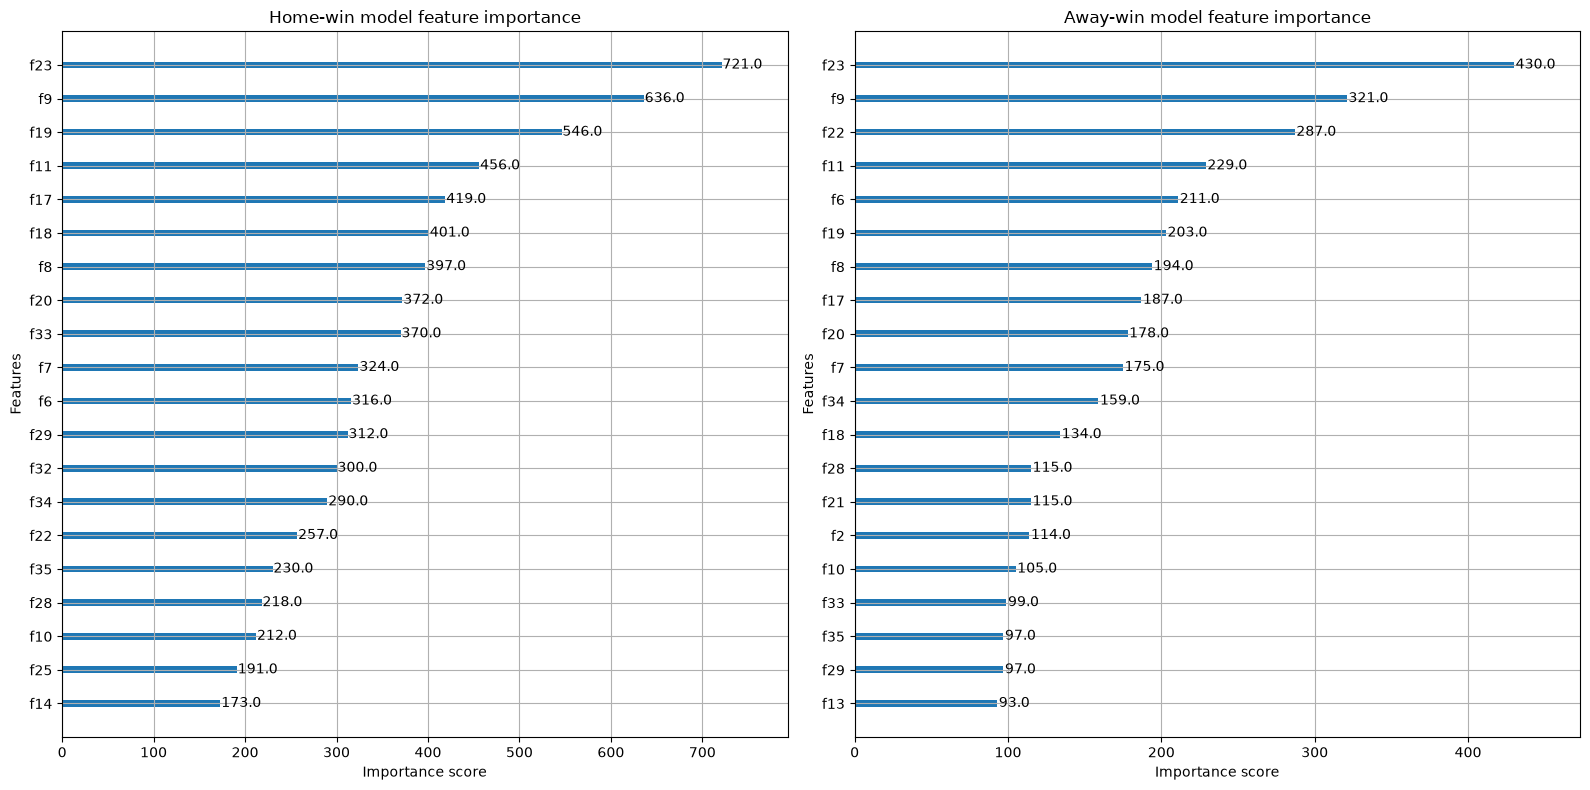

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
xgb.plot_importance(home_model, ax=axes[0], max_num_features=20)
axes[0].set_title("Home-win model feature importance")
xgb.plot_importance(away_model, ax=axes[1], max_num_features=20)
axes[1].set_title("Away-win model feature importance")
plt.tight_layout()
plt.show()
